## 2. Data Understanding

The curated dataset is a single quarterly table (`data/curated/quarterly_macro_features.csv`)
built from ABS CPI, ABS trimmed-mean CPI, RBA cash-rate decisions, RBA/ABS labour-force and
producer-price series, WTI/Brent crude, and the RBA's own published CPI forecast workbook —
joined on quarter, no manual pasting.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Image, display

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
df = pd.read_csv(CURATED)
print(f"{len(df)} quarters, {df['quarter'].iloc[0]}–{df['quarter'].iloc[-1]}, {df.shape[1]} columns")

128 quarters, 1995Q1–2026Q4, 54 columns


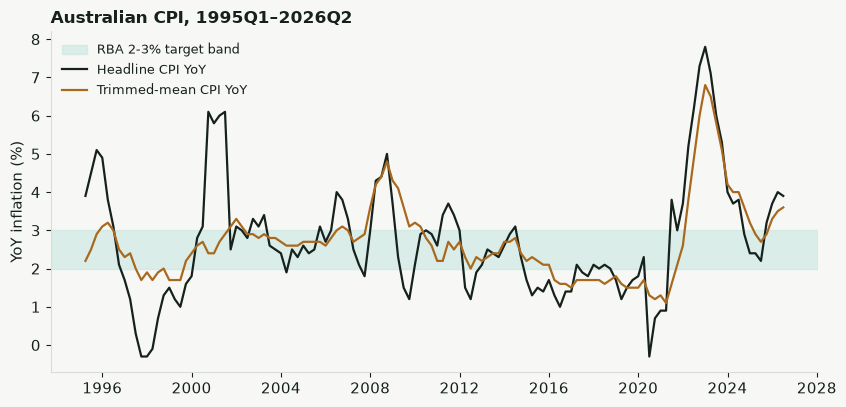

In [4]:
hist = df[["quarter", "cpi_yoy", "trimmed_mean_cpi_yoy"]].copy()
hist["quarter_date"] = pd.PeriodIndex(hist["quarter"], freq="Q").to_timestamp(how="end")

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.axhspan(2, 3, color=ACCENT_SOFT, alpha=0.5, zorder=0, label="RBA 2-3% target band")
ax.plot(hist["quarter_date"], hist["cpi_yoy"], color=INK, linewidth=1.6, label="Headline CPI YoY")
ax.plot(hist["quarter_date"], hist["trimmed_mean_cpi_yoy"], color=HIGHLIGHT, linewidth=1.6,
        label="Trimmed-mean CPI YoY")
ax.set_ylabel("YoY inflation (%)")
ax.set_title(f"Australian CPI, {hist['quarter'].iloc[0]}–2026Q2",
             loc="left", fontsize=12, fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
ax.grid(False)
plt.show()

Both series track each other closely except where headline gets pulled around by volatile
items the trimmed mean discards by construction — the GST introduction (2000-01) and the
2020 COVID childcare/fuel shock are the two sharpest headline-only spikes above.

Headline and trimmed-mean CPI are the two things being forecast. What the models lean on to
forecast them are four macro drivers, the same four that enter the SVAR system in
[§4.4](04_modeling/44_svar) (and, as lags, the Elastic Net in [§4.2](04_modeling/42_elastic_net)):

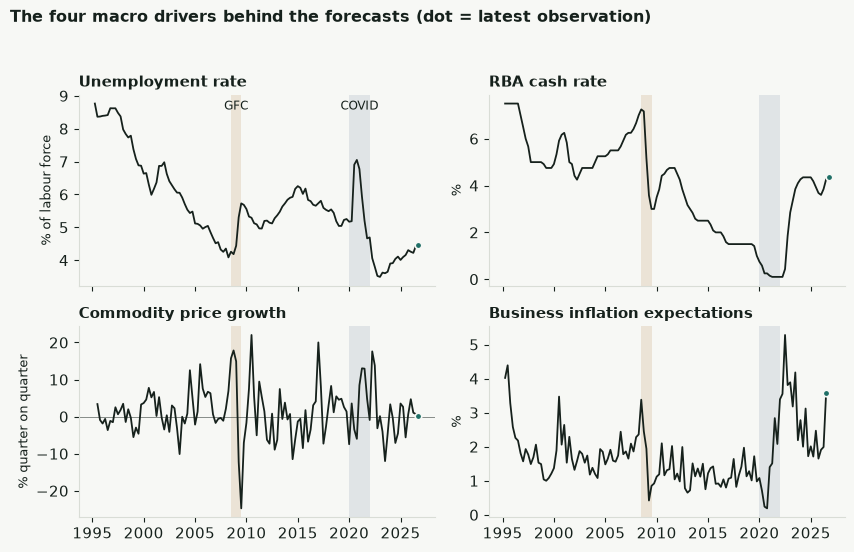

In [5]:
import matplotlib.dates as mdates

def shade_events(ax, label=False, where="top", windows=None, alpha=0.14):
    """GFC and COVID as light full-height bands: one definition of the periods and colours for the whole book.
    label=True also names each band in plain text (do that once per figure); `where` is "top" or "bottom"
    (or a {name: position} dict); `windows` overrides {name: (first quarter, last quarter, colour)}."""
    periods = {"GFC": ("2008Q3", "2009Q3", "#a8691f"), "COVID": ("2020Q1", "2022Q1", "#5b6f8f")}
    periods.update(windows or {})
    for name, (start, end, colour) in periods.items():
        s, e = pd.Period(start, "Q").to_timestamp(), pd.Period(end, "Q").to_timestamp()
        ax.axvspan(s, e, color=colour, alpha=alpha, linewidth=0, zorder=0)
        if label:
            pos = where.get(name, "top") if isinstance(where, dict) else where
            ax.text(s + (e - s) / 2, 0.97 if pos == "top" else 0.03, name, transform=ax.get_xaxis_transform(), ha="center",
                    va="top" if pos == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1)


df = pd.read_csv(CURATED)
df["date"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp(how="end")

drivers = [
    ("unemployment_rate", "Unemployment rate", "% of labour force"),
    ("cash_rate", "RBA cash rate", "%"),
    ("commodity_growth", "Commodity price growth", "% quarter on quarter"),
    ("inflation_expectations_business", "Business inflation expectations", "%"),
]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 5.6), sharex=True)
for ax, (col, title, unit) in zip(axes.ravel(), drivers):
    s = df.dropna(subset=[col])
    shade_events(ax, label=(ax is axes[0, 0]), where="top")
    if col == "commodity_growth":
        ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
    ax.plot(s["date"], s[col], color=INK, linewidth=1.3)
    ax.scatter(s["date"].iloc[-1], s[col].iloc[-1], s=22, color=ACCENT, edgecolor=PAPER, linewidth=1.2, zorder=3)
    ax.set_title(title, loc="left", fontsize=10.5, fontweight="bold")
    ax.set_ylabel(unit, fontsize=9)
    ax.grid(axis="x", visible=False)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(False)
fig.suptitle("The four macro drivers behind the forecasts (dot = latest observation)",
             x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

Two things to notice. The cash rate and unemployment are slow, persistent levels (the
stationarity consequence is in [Appendix §5](appendix_eda/05_stationarity_tests)), while commodity
growth is a noisy quarter-on-quarter change that swings both ways. Business inflation
expectations sit near 1–2% for two decades and then jump during the 2021–23 surge, which is also
when they become the strongest single predictor of headline CPI.

**Related appendix sections.** The statistical workup behind the chart above, including data quality, coverage, and each series' own behaviour live in the [Exploratory Data Analysis appendix](appendix_eda/index):

- [§1 Data Integrity Checks](appendix_eda/01_data_integrity): all 124 quarters (1995Q1–2025Q4) pass structural validation with zero duplicate or missing quarters; the 763 missing *values* it flags are columns that don't exist yet at the start of the sample, not data-quality failures.
- [§2 Missing Values And Coverage](appendix_eda/02_missing_values): the worst-coverage predictors (`household_spending_growth` 43%, `aud_usd_change` 51%, `brent_growth` 59%) aren't broken — their collection simply starts well after 1995Q1, which is why later screening treats them separately.
- [§3 CPI Target Inspection](appendix_eda/03_cpi_target_inspection) (seasonal decomposition, ACF/PACF): the extreme quarters a z-score screen flags map onto known events (2000Q3 GST, 2020Q2 COVID, 2022–23 surge), and STL confirms both CPI series have already had seasonality stripped out by the YoY transform.
- [§4 External Variable Inspection](appendix_eda/04_external_variables): a visual-only pass to catch obvious unit errors, level shifts, or gaps in the raw external series before §6/§7 run formal correlation and causality tests on them.
- [§5 Stationarity Tests](appendix_eda/05_stationarity_tests): headline `cpi_yoy` is borderline stationary at level, but `trimmed_mean_cpi_yoy`, `unemployment_rate`, and `cash_rate` are not — the mixed picture behind SVAR's choice to run in levels (§4.4).
- [§13 Raw Source Frequency Validation](appendix_eda/13_raw_frequency_validation): spot-checked `cash_rate` and `wti_price` values reconcile exactly between the raw source and curated table, confirming the ETL aggregation isn't introducing rounding errors.